# Lab 8 Euler's Method: Including Air Resistance {-}

[Jupyter Notebook](https://lancejnelson.github.io/PH150/jupyter/L8-One-Dimensional-Eulers.ipynb)

Name:

## Skills
In this lab you will gain the following skills

### Python
1. How to construct a Python `for` loop.
2. Learn the physics of air drag.
3. Construct an Euler's method code for simple one-dimensional motion.


   
## Background Information

### Review of Kinematics
Most will be familiar with the kinematic equations of motion, which can be used in situations involving constant acceleration.  The kinematic equations are.
$$v_f = v_i + a \Delta t$$
$$x_f = x_i + v_i \Delta t + {1\over 2} a \Delta t^2$$

As an example, consider a car that is initially at rest, waiting for the stoplight to turn green.  Once the light turns green, the driver presses on the accelerator and the car's speed begins to increase. After accelerating at a rate of $a = 5$ m/s$^2$ for $t = 3$ s, the driver eases up and reduces the acceleration to a more modest $a = 2$ m/s$^2$ and maintains this acceleration for another $\Delta t = 8$ s.  How would you determine the position and speed of the car after the full $11$ seconds had elapsed?  The kinematic equations above could be applied to the first 3 seconds of the trip or to the last 8 seconds of the trip, but couldn't be applied from the start to the end. Let's use the kinematic equations to determine the speed and position after the first 3 seconds.
$$ v_1 = v_0 + a_0 \Delta t$$
$$ = (0 ~\text{m/s}) + (5 ~\text{m/s}^2) (3 ~\text{s})$$
$$ = 15 ~\text{m/s}$$
$$x_1 = x_0 + v_0 \Delta t + {1\over 2} a_0 \Delta t^2$$
$$ = (0 ~\text{m}) + (0 ~\text{m/s}) (3 ~\text{s}) + {1\over 2}(5 ~\text{m/s}^2) (3 ~\text{s})^2$$
$$ = 22.5 ~\text{m}$$
Now that we have the speed and velocity at $t = 3$ we can proceed to use the same kinematic equations for the second part of the motion. 
$$ v_2 = v_1 + a_1 \Delta t$$
$$ = (15 ~\text{m/s}) + (2 ~\text{m/s}^2) (8 ~\text{s})$$
$$ = 31 ~\text{m/s}$$
$$x_2 = x_1 + v_1 \Delta t + {1\over 2} a_1 \Delta t^2$$
$$ = (22.5 ~\text{m}) + (15 ~\text{m/s}) (8 ~\text{s}) + {1\over 2}(2 ~\text{m/s}^2) (8 ~\text{s})^2$$
$$ = 206.5 ~\text{m}$$
Since the kinematic equations only apply to constant-acceleration motion, the problem had to be divided into two parts: one for each constant-acceleration portion of the motion.  
Now, what if the motion involved 5 different segments, each with a different acceleration, with the acceleration starting at 4 m/s$^2$ and decreasing by $1$ m/s$^2$ every second.

| time(s)| acceleration (m/s$^2$)|
|--------|-----------------------|
| 0 | 4 | 
| 1 | 3 | 
| 2 | 2| 
| 3 | 1 |

We could repeat the process from above to generate the positions and velocities at these four times.   

| time(s)| x(m) | v (m/s) | a (m/s$^2$)|
|--------|-----|---------|------------|
| equation | $x_{n+1} = x_n + v_n \Delta t + {1\over 2}a_n \Delta t^2$ | $v_{n+1} = v_n + a_n \Delta t$| |
| 0 | 0 | 0 | 4 | 
| 1 | 2|4|  3 | 
| 2 |7.5 |7| 2| 
| 3 | 15.5|9| 1 |

The $x_{n+1}$ and $x_n$ are standard notation to mean the next x ($x_{n+1}$) and the current x ($x_n$)

This process could be extended for as long as you wanted but I hope you can see that you don't want to do this by hand for very long.  

### Euler's Method
Most realistic scenarios involve accelerations that change **continuously**, not discretely like the examples above.  However, we can still employ the method used above if we use a time step ($\Delta t$) that is very small.  Even if the acceleration varies substantially over long time intervals, it will always be nearly constant over very small time steps.  We call this Euler's method and the steps to implement Euler's method are as follows:

1. Define the initial conditions.  For particle motion this involves defining the initial position and velocity of the object as well as any other variable that **do not change** over time.
2. Repeatedly calculate the following quantities.
   1. The current acceleration. The acceleration function is typically given to you or can be derived from Newton's law. This expression will always be a function of time,position, and/or velocity and must be re-evaluated every time you advance by a time step.
   2. Use a kinematic equation to calculate the next position using the previous position and velocity.
   3. Use a kinematic equation to calculate the next velocity using the previous position and velocity.
   4. If you want to store all of your positions and velocities for later use, append them to a list.


An example implementation of Euler's method for a particle (experiencing no air resistance) thrown upward (with $v = 30$ m/s) from an initial height of $y_i = 70$ m, is shown below. 

In [ ]:
# Import statements
import numpy as np 
import matplotlib.pyplot as plt

v0 = 30.0 # Initial velocity in m/s
y0 = 70 # Initial height in m

delta_t = 0.01 # Time step in seconds (should be small)
t0 = 0 # Start time in seconds
t_max = 7.0 #Final Time

N = (t_max - t0)/delta_t # Calculate the number of time steps

N = int(N) # Make sure N is an integer
# Make lists to store your positions, velocities and times.
y = [y0]
v = [v0]
t = [t0]

for i in range(N):
   a = -9.8  # Calculate the current acceleration

   # Store the new position, velocity, and time in the lists
   v.append(v[i] + a * delta_t)
   y.append(y[i] + v[i] * delta_t)
   t.append(t[i] + delta_t)

plt.plot(t,y,linewidth = 2, color = 'red')
plt.xlabel("time (s)")
plt.ylabel("Position (m)")
plt.title("Position vs. time for a ball in free fall")

###  The code - Broken down
This section will break the program down piece by piece. Here's the first section:

In [ ]:
"""
One Dimensional free-fall Euler Code

PH150
Brother Nelson


This code will calculate the exact solution for a ball in free fall
having been shot straight up using Euler's method.

"""
#Import numerical and plotting packages
import numpy as np
import matplotlib.pyplot as plt

Everything inside the triple quotes (""") counts as one long comment.  If you ever need to add comments that will take more than one line, you can start and end it with \"\"\".  It's a great way to leave yourself notes about what each program does.  Below the introductory comment,  numpy and matplotlib are imported to do the number crunching and plotting later on.

This next part sets up all of the constants and inputs.  It's a good idea to put it at the beginning of the program so that they are easy to change.

In [ ]:
#Initial conditions and physical setup constants
v0=30.0 #Initial velocity in m/s
x0=70 #Initial Postion in m

#Set up the time steps and number of calculations
delta_t = 0.01 #Time step in seconds
t0=0 #Start time in seconds
t_max = 7.0 #Final time

The part with `x0` and `v0` are the starting position and velocity.  `delta_t` is time step or amount of time that will advance for each calculation.  Remember, Euler's method works by assuming that acceleration is roughly constant over short time intervals.  `delta_t` sets that time interval.

With initial values defined, the number of calculations that will be needed can be determined.  Here's the piece of code that does that:

In [ ]:
#Calculate the number of timesteps we need to make
N=(t_max-t0)/delta_t
#Make sure N is an integer
N=int(N)

Python keeps two types of numbers: _Floats_ - numbers with decimal points and _Integers_ - whole numbers. For example: $2.0$ is a float, $2$ is an integer.  Even though they have the same value, Python sees them as different things. You can only get an item from a list using an integer. (`myList[2]` works, but `myList[2.0]` won't).  The command `N=int(N)` takes whatever number `N` is and converts it to an integer.  The `int` command truncates instead of rounding, so `int(2.9)` becomes `2`, not `3`.


Next, lists that will eventually store **all of the positions, velocities, and times** are initialized.  Putting square brackets around something tells Python that it is a list.  Since more x,v, and t values are going to be added later, we need to warn Python that these are going to be lists.  Initially, these lists only contain the initial values.

In [ ]:
#Make lists to hold our positions, velocities, and times
x=[x0]
v=[v0]
t=[t0]

This next section of code is what is called a loop:

In [ ]:
#| eval: False
#Now perform an Euler's method calculation.
for i in range(N):
    #Find the current acceleration
    a=-9.8
    
   # Store the new position, velocity, and time in the lists
   v.append(v[i] + a * delta_t)
   y.append(y[i] + v[i] * delta_t)
   t.append(t[i] + delta_t)

#End of Euler loop =========================================


#### Breaking down the `for` loop
For most of you, a loop will be a new idea. Loops are very helpful when you need to tell a computer to do something over and over again.  Here's the general structure:

In [ ]:
#| eval: False
for <Thing that Changes>:
     Stuff the computer does to/with the thing that changes

Not part of the loop

The code that gets inserted at: `<Thing that Changes>` should be a list of items that are to be iterated over.   As an example, consider a famous mathematical sequence of numbers called the Fibonacci sequence. The first few numbers in the Fibonacci sequence are: [1,1,2,3,5,8,13] (Can you see the pattern). A loop to iterate over this list of numbers is shown below:

In [ ]:
fibonacci = [1,1,2,3,5,8,13]
for num in fibonacci:
    print(num)

When this code is executed, the sequence of numbers first gets stored in the variable `fibonacci`.  The `for num in fibonacci` tells Python to look at each thing in the list one by one, and call it `num`, each in turn.  Therefore, this program would first print 1, then 1 (again), then 2, etc.  Once all of the numbers have been printed one at a time, the final command will execute and print the entire list.  This last statement won't execute until the loop has successfully iterated over everything in the list named `fibonacci`.

Now let's look at the `for` statement in the Euler's code: `i in range(N)`.  The `range(N)` command makes a list of integers from zero to `N-1`.  If `N` was five, `range(N)` would be `[0,1,2,3,4]`.  Therefore, the first time through the for loop `i=0`, the second time `i=1`, and so on until we reach `N-1`.

Now let's look at the inside of the loop:

In [ ]:
#| eval: False
    #Find the current acceleration
    a=-9.8
    
   # Store the new position, velocity, and time in the lists
   v.append(v[i] + a * delta_t)
   y.append(y[i] + v[i] * delta_t)
   t.append(t[i] + delta_t)

This is where  Euler's method is found.  First the acceleration is calculated, which is a constant -9.8 in this case but usually will be a function of time, position, and/or velocity. The next statement involves an `append` statement:

In [ ]:
#| eval: False
   v.append(v[i] + a * delta_t)

The `append` statement is used to add something to the end of a list. In this case, the statement `v.append(v[i]+a*delta_t)` adds `v[i]+a*delta_t` to the end of the list named `v`.   This is nothing more than the kinematic equation $v_f=v_i+a\Delta t$, using `v[i]` as $v_i$ to calculate the "final" velocity.  Each time the computer goes through the loop, a different value for `i` is used, and therefore a different value for `v[i]`.  If the list starts with just one value in it (`v=[0]`), then by the end of the first iteration there are two things in the list. (The same can be said for the position and time lists) 

The first few iterations of this loop are done by hand and placed in the table below to help you see exactly what the loop is doing.


In [ ]:
#| eval: True
#| echo: False
#| output: True
from pandas import DataFrame
import numpy as np
t = [0]
y = [70]
v = [30]
dt = 0.1
for i in range(3):
    a = -9.8
    y.append(y[-1] + v[-1] * dt)
    v.append(v[-1] + a * dt)
    t.append(t[-1] + dt)

df = DataFrame(np.transpose([t,y,v]),columns = ["time", r"$$y_f = y_i + v_i \Delta t$$", r"$$v_f = v_i + a \Delta t$$"])
display(df)

Velocity can be used to calculate the position using the kinematic equation $x_f=x_i+v_i\Delta t+\frac{1}{2}a\Delta t^2$.  The term $\frac{1}{2}a\Delta t^2$ is neglected because if $\Delta t$ is small then $\Delta t^2$ will be very small, making this entire term inconsequential. Once the loop is finished, the program just builds a plot of the data:

In [ ]:
#| eval: False
#Plot the results
plt.plot(t,x,linewidth=2,color='red')
plt.xlabel('time (s)')
plt.ylabel('Position (m)')
plt.title('Position vs. time for a ball in free fall')

### Air Drag
This week we will be using Euler's method to predict the fall time for an object experiencing a non-negligible amount of drag.  The drag force acting on a falling object is given by:

$$F_D =  {1\over 2} \; C \rho A v^2 \;\;\;\;\;(1) $$  

where $C$ is the drag coefficeint and has the following values:
       0.5 for a sphere and 0.3 for a cone.
       
$\rho$ is the air density and has a value of 1.02  kg/m$^3$ in Rexburg

A is the cross-sectional area

v is the velocity of the object

<div style="text-align: center;">
<img src="https://github.com/lancejnelson/PH121/raw/gh-pages/files/numericalHW/fbd.png" alt="drawing" width="125px"/>
</div>



Applying Newton's second law to the free-body diagram shown above gives:

$$ \Sigma F_{y} = -mg + F_{D} = ma_{y} \;\;\;\;\;(2) $$


Solving for the acceleration in the y-direction gives:

$$ a_y = {d v_y \over dt} = \frac{ C \rho A v^{2}}{2m} - g \;\;\;\;\;(3)$$

Notice that this expression for the acceleration is not constant; it changes as $v$ changes.  The kinematic equations can be used to update the position and velocity
$$ y_{n+1} = y_{n} + v_{n} \cdot \Delta t \;\;\;\;\;(5)$$

$$ v_{n+1} = v_{n} + a_{n} \cdot \Delta t \;\;\;\;\;(6)$$

$$ = v_{n} + ({C \rho A v^2 \over 2 m} - g) \cdot \Delta t \;\;\;\;\;(6)$$


## Python skills
In this lab you will need to use programming loops to use Euler's method. _Loops_ allow programs to rerun the same block of code multiple times.  This might seem like a funny thing to want to do but it turns out that there are many important tasks that are repetitive in nature (perhaps with small changes for each successive repetition).  A loop provides a succinct and efficient way to perform tasks of this nature.

### For loop
The `for` loop is probably the most common loop you will encounter and is a good choice when you know beforehand exactly what things you want to loop over.  Here is an example of a `for` loop that is used to add up the elements of a list.

In [ ]:
thesum = 0
for i in [3,2,1,9.9]: 
    thesum += i

 This would be equivalent to the following code:

In [ ]:
thesum = 0

thesum = thesum + 3
thesum = thesum + 2
thesum = thesum + 1
thesum = thesum + 9.9

which isn't that much longer than using a loop.  However, as the list gets longer and/or the mathematical operations being performed get more complex the second method would get unreasonably long.


The correct language is to say that we are _iterating_ over the list `[3,2,1,9.9]`.  This
means that the loop variable (`i` in this case but you can choose it to be whatever you want) gets assigned
the values of the list elements, one by one, until it reaches the end
of the list.  You can use `for` loops to iterate over any multi-element object like lists or tuples.  Python uses indentation to indicate
where the loop ends. In this case there was only one statement inside to loop, but if you wanted more than one each line should be indented.  


Often you will want to iterate over a list of integers. The `range` function is a good choice for this. The range function takes up to 3 arguments. The first is the starting number, the second is the ending number, and the third is the step size.

`range(start,stop,stepsize)`


In [ ]:
for i in range(5,50,3):  #Generates a list from 5 -> 50 with a step size of 3
    print(i)

These examples are so simple that you might wonder when a loop might
actually be useful to you.  Let's see if we can build a loop to
calculate the following sum

$$ \sum_{n=1}^{1000} {1\over n^2}$$ {#eq-sum}

In [ ]:
theSum = 0
for n in range(1,1000):
    theSum = theSum + 1/n**2
print(theSum)

Here, `n` is being assigned the values
`1,2,3,4....1000`, one by one, until it gets all the way to
1000.  Each time through the loop, `n` is different
and the expression `1/n**2` evaluates to a new value.  The
variable `theSum` is updated each time through to be the
running total of all calculations performed thus far.  Here's another
example of a loop used to calculate the value of $20!$:

In [ ]:
theProduct = 1
for n in range(1,21):
    theProduct = theProduct * n #Multiply theProduct by n
print(theProduct)

Remember that the range function creates a list starting at $1$, going
up to $21$ but not including it. The math library has a function
called `factorial` that does the same thing.  Let's use it to
check our answer:

In [ ]:
from math import factorial
factorial(20)

### Boolean logic inside loops

Often when using loops, we only want a block of code to execute when some condition is satisfied.
We can use boolean logic inside of the loop to accomplish this. For example, let's write a loop to compute the following sum:

$$ \sum_{{n\over 5} \in \text{ Int and } {n\over 3} \in \text{ Int}} {1\over n^2} $$

which is similar to the one we did above, but this time  we only want to include terms where $n$ is a perfect multiple of both 5 and 3. To check to see if `n` is a perfect multiple of a number we can calculate the modulo (remainder after division) using the `%` operator and check that it is equal to zero.

In [ ]:
theSum = 0
for n in range(1,1000):
    if n % 5 == 0 and n % 3 == 0:
        theSum = theSum + 1/n**2
print(theSum)

## Activity I: Minimum Fall Time

### Goal (Overview)
Using kinematics, calculate the time it takes for a particle to fall, starting from rest, through a distance of $6$ meters, neglecting air drag. This number will serve as a point of comparison when we include air drag in our analysis.


### Procedure
1. The kinematic equations are given below.
$$y_f = y_i + v_i \Delta t + {1\over 2}a \Delta t^2$$  $$v_f = v_i + a \Delta t$$  $$v_f^2 = v_i^2 + 2 a \Delta x$$ 
Use these equations to calculate the time it takes for a particle to fall through a distance of $6.0$ meters starting from rest. Neglect air resistance.  Show your math and calculations below.

> Include kinematic details here

In [1]:
# Code to perform calculations here
import numpy as np
d = 6.0
g = 9.8
t = np.sqrt(2 * d/g)

print(t)

1.1065666703449761


## Activity II: Modeling the motion using Euler's method

### Goal (Overview)
Write some python code that will accurately predict the fall time for a projectile that is experiencing air resistance.  

### Procedure
1. In the example discussed above, a model for a particle that is thrown upward and experiences no air resistance was constructed.  Use equations 3-6 from the "Air Drag" section to modify that code to include air resistance.  Set $\rho = 1.02$ kg/m$^3$, $C = 0.5$ and make reasonable guesses for the values of $A$ and $m$. We'll fine tune these values later.
2. Modify the code to model a particle that is dropped from rest rather than thrown upward initially.
3. Your value for $\Delta t$ will need to be reasonably small to get accurate results.  Decrease your value of $\Delta t$ until the results stop changing.
4. To find the flight time, you should use trial and error on t_max until the particle hits the ground.
5. As a test of the correctness of your code, increase the initial height of the projectile and verify that the drop time changes as you would expect. 
6. As a test of the correctness of your code, increase the mass of the projectile and verify that the drop time changes as you would expect.
7. As a test of the correctness of your code, decrease the drag constant of the projectile and verify that the drop time changes as you would expect. 


(0.0, 8.0)

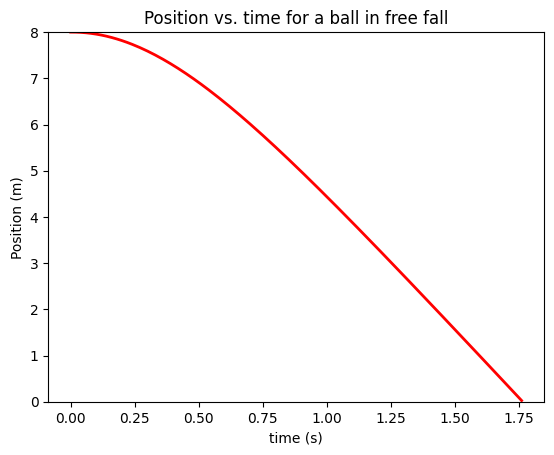

In [10]:
#| eval: false
#| echo: true
# Import statements
import numpy as np 
import matplotlib.pyplot as plt

v0 = 0.0 # Initial velocity in m/s
y0 = 8 # Initial height in m
ρ = 1.23  # Density of air
r = 0.1
A = np.pi * r**2  #Cross-sectional area
m = .035  # Mass
C = 0.5 # Drag constant
g = 9.8 # Acceleration due to gravity

delta_t = 0.01 # Time step in seconds (should be small)
t0 = 0 # Start time in seconds
t_max = 1.76 #Final Time

N = (t_max - t0)/delta_t # Calculate the number of time steps

N = int(N) # Make sure N is an integer
# Make lists to store your positions, velocities and times.
y = [y0]
v = [v0]
t = [t0]

for i in range(N):
    Fd = 1/2 * ρ * A * C * v[-1]**2
    a = (Fd - m * g)/m
   # Store the new position, velocity, and time in the lists
    v.append(v[i] + a * delta_t)
    y.append(y[i] + v[i] * delta_t)
    t.append(t[i] + delta_t)

plt.plot(t,y,linewidth = 2, color = 'red')
plt.xlabel("time (s)")
plt.ylabel("Position (m)")
plt.title("Position vs. time for a ball in free fall")
plt.ylim(0,y0)

## Activity III: Predicting times

### Procedure
1. Make mass and diameter measurements on each of the objects given to you. 
2. Choose a location to perform the drop and measure the initial height. You should find a location that provides a large drop distance.  (The track above the I-center or the foyer in the Manwaring center are good choices.  We've dropped them from the top of the stadium before but a tall fence was recently installed which makes it hard to drop from there. )
3. Then use the code you wrote above to predict the drop times for each of the six objects.
4. Fill in the table below with your predictions. 

|Object | Mass (kg) | Diameter (m) |Precited fall time (s)|
|-------|-----------|--------------|----------------------|
|Ping Pong Ball |   |              |            |
|Styrofoam cone |   |              |            |
|Styrofoam sphere (small) |   |              |            |
|Styrofoam sphere (medium) |   |              |            |
|Beach ball |   |              |            |




## Activity IV: Comparison of Predicted and Measured Times

1. Measure the flight time for each object $10$ times. 
2. Calculate the average fall time for each object.
3. Calculate the percent error for each object.
4. Fill in your results in the table below.

$$ \text{% diff} = {\text{measured} - \text{predicted} \over \text{measured} } \times 100 \text{%}$$

|Object | Precited fall time (s)|  Average measured fall Time (s)| % Error|
|-------|-----------------------|-----------------|--------|
|Ping Pong Ball |               | | |
|Styrofoam cone |               | | |
|Styrofoam sphere (small) |               | | |
|Styrofoam sphere (medium) |               | | |
|Beach ball |               | | |


Your score on the lab will be based on your % error for the five different objects.


If any of your % differences are greater than 10%, give a possible explanation for the discrepancy.
> **Response:**


In [ ]:
#| eval: false
#| echo: true

# Python code here